## Code to process nurse validation results

In [1]:
import pandas as pd
from pathlib import Path

validation_dir = Path(r"D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_validation")
master_path = validation_dir / "MASTER_assignments.xlsx"

results_dir = validation_dir / "results"
results_dir.mkdir(exist_ok=True)

print(validation_dir.exists())
print(master_path.exists())

True
True


In [2]:
master = pd.read_excel(master_path)

master.head()

,nurse,image_number_for_nurse,assigned_filename,original_filename,original_path,patient_id,original_stage_if_available
0,nurse_01,1,0001.jpg,1771.jpg,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...,2069,2
1,nurse_01,2,0002.jpg,581.jpg,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...,1247,4
2,nurse_01,3,0003.jpg,2082.jpg,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...,2259,1
3,nurse_01,4,0004.jpg,808.jpg,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...,1410,4
4,nurse_01,5,0005.jpg,2038.jpg,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...,2203,4


In [ ]:
all_validations = []

for nurse_folder in sorted(validation_dir.glob("nurse_*")):
    if not nurse_folder.is_dir():
        continue

    nurse_name = nurse_folder.name
    
    excel_files = list(nurse_folder.glob("*.xlsx"))
    
    if len(excel_files) == 0:
        print(f"No hay Excel en {nurse_name}")
        continue
    
    # normalmente habrá solo uno
    excel_path = excel_files[0]
    
    df = pd.read_excel(excel_path)
    df["nurse"] = nurse_name
    df["source_excel"] = str(excel_path)
    
    all_validations.append(df)
    
    print(nurse_name, len(df), excel_path.name)

validations = pd.concat(all_validations, ignore_index=True)

validations.head()

nurse_01 300 nurse_01_validation_template.xlsx
nurse_02 300 nurse_02_validation_template.xlsx
nurse_03 300 nurse_03_validation_template.xlsx
nurse_04 200 nurse_04_validation_template.xlsx
nurse_05 200 nurse_05_validation_template.xlsx
nurse_06 200 nurse_06_validation_template.xlsx
nurse_07 215 nurse_07_validation_template.xlsx
nurse_08 215 nurse_08_validation_template.xlsx
nurse_09 215 nurse_09_validation_template.xlsx
nurse_10 215 nurse_10_validation_template.xlsx
nurse_11 215 nurse_11_validation_template.xlsx
nurse_12 215 nurse_12_validation_template.xlsx
nurse_13 214 nurse_13_validation_template.xlsx
nurse_14 214 nurse_14_validation_template.xlsx
nurse_15 214 nurse_15_validation_template.xlsx
nurse_16 214 nurse_16_validation_template.xlsx
nurse_17 214 nurse_17_validation_template.xlsx


,image_number,stage_1_to_5,comments,nurse,source_excel,Unnamed: 1,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,...,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,1,3.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,3.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,5.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,4.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,4.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
validations.columns

Index(['image_number', 'stage_1_to_5', 'comments', 'nurse', 'source_excel',
       'Unnamed: 1', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17'],
      dtype='object')

In [5]:
validations = validations.rename(columns={
    "image_number": "image_number_for_nurse",
    "stage_1_to_5": "nurse_stage"
})

validations["image_number_for_nurse"] = validations["image_number_for_nurse"].astype(str).str.zfill(4)
validations["nurse_stage"] = pd.to_numeric(validations["nurse_stage"], errors="coerce")

validations.head()

,image_number_for_nurse,nurse_stage,comments,nurse,source_excel,Unnamed: 1,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,...,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,0001,3.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0002,3.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0003,5.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0004,4.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0005,4.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Eliminar columnas vacías tipo Unnamed
validations = validations.loc[:, ~validations.columns.str.startswith("Unnamed")]

# Dejar solo columnas útiles
validations = validations[
    ["image_number_for_nurse", "nurse_stage", "comments", "nurse", "source_excel"]
]

validations.head()

,image_number_for_nurse,nurse_stage,comments,nurse,source_excel
0,0001,3.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
1,0002,3.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
2,0003,5.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
3,0004,4.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
4,0005,4.0,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...


In [7]:
print("Total validaciones leídas:", len(validations))
print("Valores de stage:")
print(validations["nurse_stage"].value_counts(dropna=False).sort_index())

print("\nValidaciones sin número:")
validations[validations["nurse_stage"].isna()].head(20)

Total validaciones leídas: 3860
Valores de stage:
nurse_stage
0.0      16
1.0     111
2.0    1021
3.0     899
4.0     726
5.0     208
NaN     879
Name: count, dtype: int64

Validaciones sin número:


,image_number_for_nurse,nurse_stage,comments,nurse,source_excel
134,0135,NaN,no,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
242,0243,NaN,no es presión,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
255,0256,NaN,no es presión,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
259,0260,NaN,no es presión,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
260,0261,NaN,no es presion,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
264,0265,NaN,no es presión,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
291,0292,NaN,resuelta,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
292,0293,NaN,NaN,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
295,0296,NaN,no es presión,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...
296,0297,NaN,no es presión,nurse_01,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...


In [8]:
# Ver comentarios únicos más frecuentes
validations["comments_clean"] = (
    validations["comments"]
    .astype(str)
    .str.lower()
    .str.strip()
)

comment_counts = (
    validations["comments_clean"]
    .value_counts()
    .head(50)
)

comment_counts

comments_clean
nan                                                                                                  3254
humedad                                                                                                51
no valorable                                                                                           39
no es pot valorar be nomes amb imatge                                                                  32
no se observa profundidad                                                                              17
cavitada, dificil valorar profundidad                                                                  16
no valorable/ profundidad                                                                              13
lescah ciia                                                                                            12
escara necrótica                                                                                        9
presencia de mucho esfacelo, no

In [ ]:
def classify_case(row):
    
    stage = row["nurse_stage"]
    comment = str(row["comments_clean"]).lower()
    
    
    # VALID STAGE
    
    
    if pd.notna(stage) and stage in [1,2,3,4,5]:
        return "valid_stage"
    
    
    # INVALID 0
    
    
    if stage == 0:
        return "possible_empty_or_invalid"
    
    
    # NOT PRESSURE INJURY
    
    
    not_pressure_keywords = [
        "no es presión",
        "no es presion",
        "humedad",
        "lesion por humedad",
        "dehiscencia",
        "traqueostoma",
        "cicatriz",
        "resuelta"
    ]
    
    if any(k in comment for k in not_pressure_keywords):
        return "not_pressure_injury"
    
    
    # NOT ASSESSABLE
    
    
    not_assessable_keywords = [
        "no valorable",
        "no categorizable",
        "no se observa profundidad",
        "no es pot valorar",
        "no puedo valorar",
        "no se aprecia",
        "difícil valorar",
        "dificil valorar",
        "se desconoce profundidad"
    ]
    
    if any(k in comment for k in not_assessable_keywords):
        return "not_assessable"
    
    
    # EMPTY
    
    
    if pd.isna(stage) and (comment == "nan" or comment.strip() == ""):
        return "unknown_empty"
    
    return "other_comment"

In [11]:
validations["validation_type"] = validations.apply(classify_case, axis=1)

validations["validation_type"].value_counts()

validation_type
valid_stage                  2965
unknown_empty                 609
other_comment                 115
not_assessable                 88
not_pressure_injury            67
possible_empty_or_invalid      16
Name: count, dtype: int64

In [13]:
master["image_number_for_nurse"] = (
    master["image_number_for_nurse"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(4)
)

validations["image_number_for_nurse"] = (
    validations["image_number_for_nurse"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(4)
)

In [14]:
merged = master.merge(
    validations,
    on=["nurse", "image_number_for_nurse"],
    how="left"
)

merged.head()

,nurse,image_number_for_nurse,assigned_filename,original_filename,original_path,patient_id,original_stage_if_available,nurse_stage,comments,source_excel,comments_clean,validation_type
0,nurse_01,0001,0001.jpg,1771.jpg,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...,2069,2,3.0,NaN,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,nan,valid_stage
1,nurse_01,0002,0002.jpg,581.jpg,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...,1247,4,3.0,NaN,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,nan,valid_stage
2,nurse_01,0003,0003.jpg,2082.jpg,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...,2259,1,5.0,NaN,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,nan,valid_stage
3,nurse_01,0004,0004.jpg,808.jpg,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...,1410,4,4.0,NaN,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,nan,valid_stage
4,nurse_01,0005,0005.jpg,2038.jpg,D:\Documentos\UPC\GUTTMANN\demo2\data\raw\phot...,2203,4,4.0,NaN,D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_va...,nan,valid_stage


In [15]:
print(len(master), len(validations), len(merged))
print(merged["nurse_stage"].isna().sum())

3860 3860 3860
879


1. AGREEMENT ANALYSIS

In [16]:
grouped = (
    merged
    .groupby(
        ["original_filename", "original_path"]
    )
    .agg(
        nurses=("nurse", list),
        stages=("nurse_stage", list),
        validation_types=("validation_type", list),
        comments=("comments", list),
        n_validations=("nurse_stage", "size")
    )
    .reset_index()
)

In [18]:
grouped["n_validations"].value_counts()

n_validations
2    1907
4      10
6       1
Name: count, dtype: int64

In [31]:
grouped = (
    merged
    .groupby(
        ["original_path"]
    )
    .agg(
        original_filename=("original_filename", "first"),
        nurses=("nurse", list),
        stages=("nurse_stage", list),
        validation_types=("validation_type", list),
        comments=("comments", list),
        n_validations=("nurse_stage", "size")
    )
    .reset_index()
)

In [32]:
grouped["n_validations"].value_counts()

n_validations
2    1907
4      10
6       1
Name: count, dtype: int64

In [33]:
valid_grouped = grouped[grouped["n_validations"] == 2].copy()

print(len(valid_grouped))

1907


In [34]:
def safe_get(lst, idx):
    try:
        return lst[idx]
    except:
        return None

valid_grouped["stage_1"] = valid_grouped["stages"].apply(lambda x: safe_get(x, 0))
valid_grouped["stage_2"] = valid_grouped["stages"].apply(lambda x: safe_get(x, 1))

valid_grouped["validation_1"] = valid_grouped["validation_types"].apply(lambda x: safe_get(x, 0))
valid_grouped["validation_2"] = valid_grouped["validation_types"].apply(lambda x: safe_get(x, 1))

valid_grouped["comment_1"] = valid_grouped["comments"].apply(lambda x: safe_get(x, 0))
valid_grouped["comment_2"] = valid_grouped["comments"].apply(lambda x: safe_get(x, 1))

In [ ]:
def determine_case(row):

    v1 = row["validation_1"]
    v2 = row["validation_2"]

    s1 = row["stage_1"]
    s2 = row["stage_2"]

    
    # Ambos stages válidos
    

    if v1 == "valid_stage" and v2 == "valid_stage":

        if s1 == s2:
            return "agreement_valid_stage"
        else:
            return "disagreement_stage"

    
    # Ambos no valorables
    

    if v1 == "not_assessable" and v2 == "not_assessable":
        return "both_not_assessable"

    
    # Ambos no presión
    

    if v1 == "not_pressure_injury" and v2 == "not_pressure_injury":
        return "both_not_pressure"

    
    # Uno válido y otro no
    # o cualquier mezcla rara
    

    return "mixed_or_uncertain"

In [36]:
valid_grouped["final_case_type"] = valid_grouped.apply(determine_case, axis=1)

valid_grouped["final_case_type"].value_counts()

final_case_type
mixed_or_uncertain       782
agreement_valid_stage    608
disagreement_stage       512
both_not_pressure          3
both_not_assessable        2
Name: count, dtype: int64

In [37]:
agreement_cases = valid_grouped[
    valid_grouped["final_case_type"] == "agreement_valid_stage"
]

disagreement_cases = valid_grouped[
    valid_grouped["final_case_type"] == "disagreement_stage"
]

mixed_cases = valid_grouped[
    valid_grouped["final_case_type"] == "mixed_or_uncertain"
]

In [74]:
disagreement_cases[
    ["stage_1", "stage_2"]
].value_counts().head(30)

stage_1  stage_2
3.0      4.0        135
2.0      3.0        105
3.0      2.0         73
4.0      3.0         45
2.0      4.0         25
         1.0         20
1.0      2.0         16
5.0      4.0         16
3.0      5.0         16
4.0      5.0         11
2.0      5.0         11
5.0      2.0          9
4.0      2.0          9
5.0      3.0          8
1.0      5.0          4
5.0      1.0          3
4.0      1.0          3
3.0      1.0          2
1.0      3.0          1
Name: count, dtype: int64

In [39]:
disagreement_cases["pair"] = disagreement_cases.apply(
    lambda row: tuple(sorted([row["stage_1"], row["stage_2"]])),
    axis=1
)

C:\Users\ahont\AppData\Local\Temp\ipykernel_6308\3362233381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disagreement_cases["pair"] = disagreement_cases.apply(


In [40]:
pair_counts = (
    disagreement_cases["pair"]
    .value_counts()
    .reset_index()
)

pair_counts.columns = ["stage_pair", "count"]

pair_counts

,stage_pair,count
0,"(3.0, 4.0)",180
1,"(2.0, 3.0)",178
2,"(1.0, 2.0)",36
3,"(2.0, 4.0)",34
4,"(4.0, 5.0)",27
5,"(3.0, 5.0)",24
6,"(2.0, 5.0)",20
7,"(1.0, 5.0)",7
8,"(1.0, 3.0)",3
9,"(1.0, 4.0)",3


In [41]:
pair_counts["percentage"] = (
    pair_counts["count"] /
    pair_counts["count"].sum()
) * 100

pair_counts["percentage"] = pair_counts["percentage"].round(2)

pair_counts

,stage_pair,count,percentage
0,"(3.0, 4.0)",180,35.16
1,"(2.0, 3.0)",178,34.77
2,"(1.0, 2.0)",36,7.03
3,"(2.0, 4.0)",34,6.64
4,"(4.0, 5.0)",27,5.27
5,"(3.0, 5.0)",24,4.69
6,"(2.0, 5.0)",20,3.91
7,"(1.0, 5.0)",7,1.37
8,"(1.0, 3.0)",3,0.59
9,"(1.0, 4.0)",3,0.59


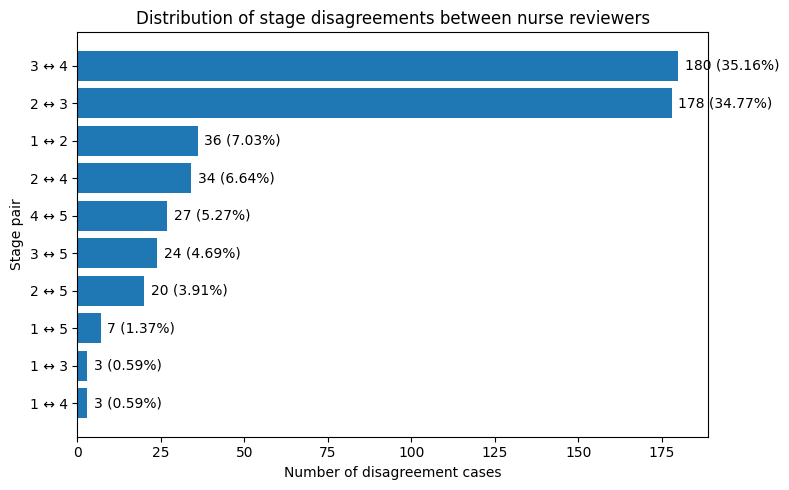

In [42]:
import matplotlib.pyplot as plt

# Crear etiqueta bonita
pair_counts = pair_counts.copy()
pair_counts["stage_pair_label"] = pair_counts["stage_pair"].apply(
    lambda x: f"{int(x[0])} ↔ {int(x[1])}"
)

# Ordenar de menor a mayor para que el mayor quede arriba en barh
plot_df = pair_counts.sort_values("count", ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(plot_df["stage_pair_label"], plot_df["count"])

plt.xlabel("Number of disagreement cases")
plt.ylabel("Stage pair")
plt.title("Distribution of stage disagreements between nurse reviewers")

# Añadir etiquetas count + porcentaje
for bar, count, pct in zip(bars, plot_df["count"], plot_df["percentage"]):
    plt.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({pct:.2f}%)",
        va="center"
    )

plt.tight_layout()
plt.show()

In [43]:
from sklearn.metrics import cohen_kappa_score

stage_cases = valid_grouped[
    (valid_grouped["validation_1"] == "valid_stage") &
    (valid_grouped["validation_2"] == "valid_stage")
].copy()

print("Images with two valid stage labels:", len(stage_cases))

kappa = cohen_kappa_score(
    stage_cases["stage_1"],
    stage_cases["stage_2"]
)

weighted_kappa_linear = cohen_kappa_score(
    stage_cases["stage_1"],
    stage_cases["stage_2"],
    weights="linear"
)

weighted_kappa_quadratic = cohen_kappa_score(
    stage_cases["stage_1"],
    stage_cases["stage_2"],
    weights="quadratic"
)

print("Cohen's Kappa:", round(kappa, 4))
print("Linear Weighted Kappa:", round(weighted_kappa_linear, 4))
print("Quadratic Weighted Kappa:", round(weighted_kappa_quadratic, 4))

Images with two valid stage labels: 1120
Cohen's Kappa: 0.3705
Linear Weighted Kappa: 0.4837
Quadratic Weighted Kappa: 0.5659


In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
print(len(stage_cases))

1120


In [46]:
cm = confusion_matrix(
    stage_cases["stage_1"],
    stage_cases["stage_2"],
    labels=[1,2,3,4,5]
)

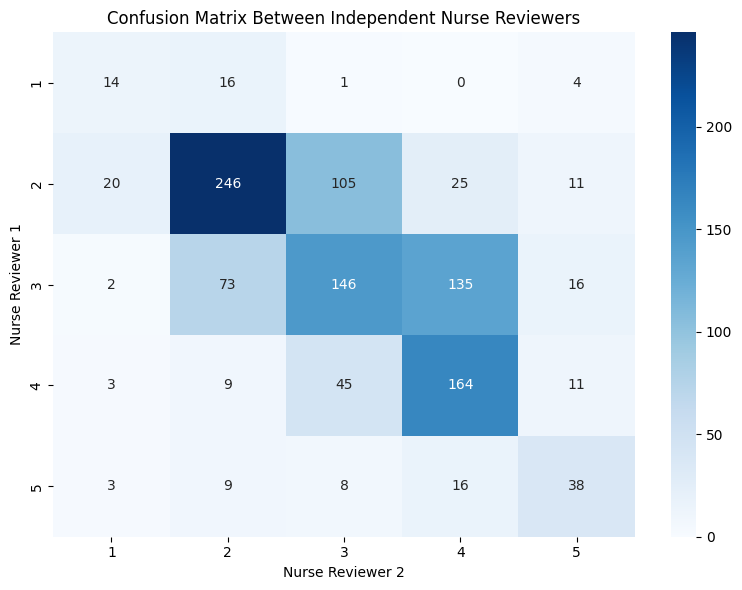

In [47]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Nurse Reviewer 2")
plt.ylabel("Nurse Reviewer 1")
plt.title("Confusion Matrix Between Independent Nurse Reviewers")

plt.tight_layout()
plt.show()

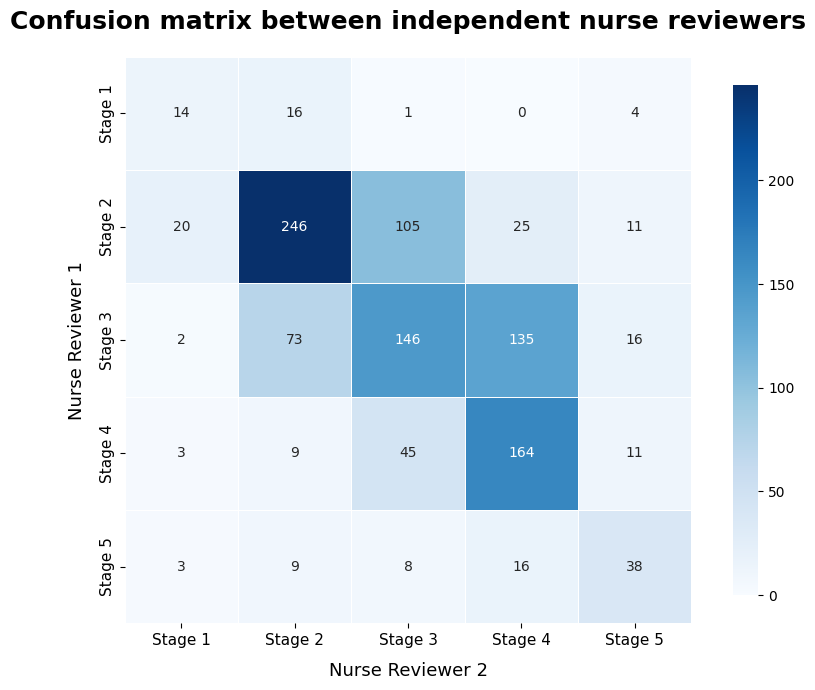

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.9},
    xticklabels=["Stage 1", "Stage 2", "Stage 3", "Stage 4", "Stage 5"],
    yticklabels=["Stage 1", "Stage 2", "Stage 3", "Stage 4", "Stage 5"]
)

plt.title(
    "Confusion matrix between independent nurse reviewers",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Nurse Reviewer 2",
    fontsize=13,
    labelpad=10
)

plt.ylabel(
    "Nurse Reviewer 1",
    fontsize=13,
    labelpad=10
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

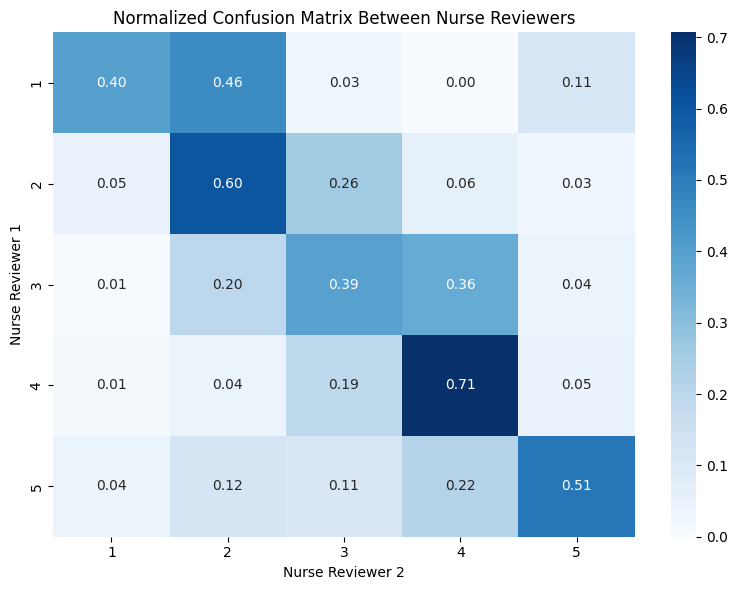

In [76]:
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, None]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Nurse Reviewer 2")
plt.ylabel("Nurse Reviewer 1")
plt.title("Normalized Confusion Matrix Between Nurse Reviewers")

plt.tight_layout()
plt.show()

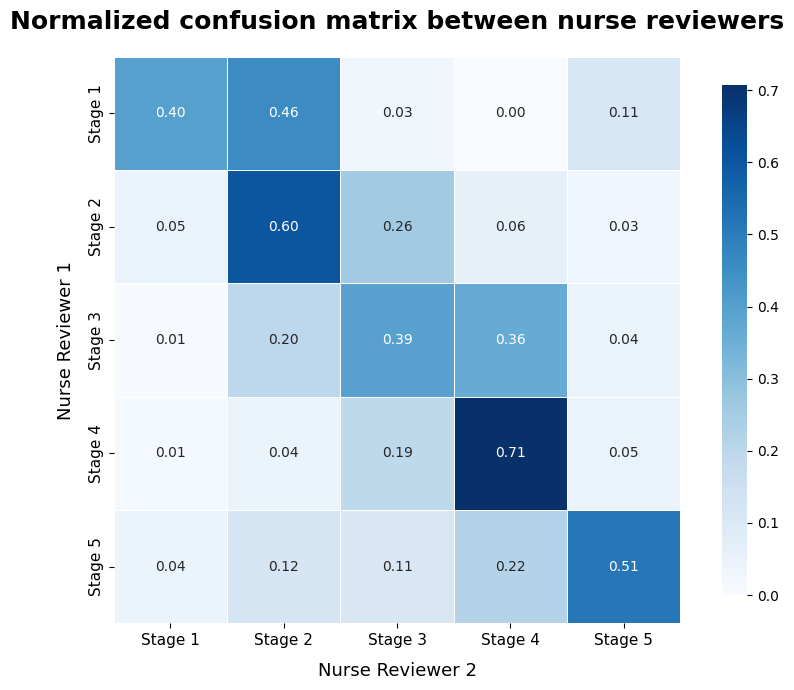

In [80]:
cm_normalized = cm.astype(float) / cm.sum(axis=1)[:, None]

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.9},
    xticklabels=["Stage 1", "Stage 2", "Stage 3", "Stage 4", "Stage 5"],
    yticklabels=["Stage 1", "Stage 2", "Stage 3", "Stage 4", "Stage 5"]
)

plt.title(
    "Normalized confusion matrix between nurse reviewers",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Nurse Reviewer 2",
    fontsize=13,
    labelpad=10
)

plt.ylabel(
    "Nurse Reviewer 1",
    fontsize=13,
    labelpad=10
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

ORIGINAL DATASET COMPARISON

In [49]:
agreement_dataset = valid_grouped[
    valid_grouped["final_case_type"] == "agreement_valid_stage"
].copy()

agreement_dataset["consensus_stage"] = agreement_dataset["stage_1"]

print(len(agreement_dataset))

608


In [50]:
agreement_dataset[
    [
        "original_filename",
        "stage_1",
        "stage_2"
    ]
].head()

,original_filename,stage_1,stage_2
7,1009.jpg,2.0,2.0
19,1034.jpg,3.0,3.0
20,1035.jpg,3.0,3.0
21,1036.jpg,4.0,4.0
26,1040.jpg,3.0,3.0


In [51]:
grouped = (
    merged
    .groupby(["original_path"])
    .agg(
        original_filename=("original_filename", "first"),
        original_stage_if_available=("original_stage_if_available", "first"),
        nurses=("nurse", list),
        stages=("nurse_stage", list),
        validation_types=("validation_type", list),
        comments=("comments", list),
        n_validations=("nurse_stage", "size")
    )
    .reset_index()
)

In [52]:
valid_grouped = grouped[grouped["n_validations"] == 2].copy()

In [53]:
valid_grouped["stage_1"] = valid_grouped["stages"].apply(lambda x: safe_get(x, 0))
valid_grouped["stage_2"] = valid_grouped["stages"].apply(lambda x: safe_get(x, 1))

valid_grouped["validation_1"] = valid_grouped["validation_types"].apply(lambda x: safe_get(x, 0))
valid_grouped["validation_2"] = valid_grouped["validation_types"].apply(lambda x: safe_get(x, 1))

valid_grouped["comment_1"] = valid_grouped["comments"].apply(lambda x: safe_get(x, 0))
valid_grouped["comment_2"] = valid_grouped["comments"].apply(lambda x: safe_get(x, 1))

valid_grouped["final_case_type"] = valid_grouped.apply(determine_case, axis=1)

In [54]:
agreement_dataset = valid_grouped[
    valid_grouped["final_case_type"] == "agreement_valid_stage"
].copy()

agreement_dataset["consensus_stage"] = agreement_dataset["stage_1"]

print(len(agreement_dataset))

608


In [55]:
agreement_with_original = (
    agreement_dataset["original_stage_if_available"] ==
    agreement_dataset["consensus_stage"]
).mean()

print(
    "Agreement with original labels:",
    round(agreement_with_original * 100, 2),
    "%"
)

Agreement with original labels: 67.6 %


In [56]:
from sklearn.metrics import cohen_kappa_score

original_kappa = cohen_kappa_score(
    agreement_dataset["original_stage_if_available"],
    agreement_dataset["consensus_stage"]
)

original_weighted_kappa = cohen_kappa_score(
    agreement_dataset["original_stage_if_available"],
    agreement_dataset["consensus_stage"],
    weights="quadratic"
)

print("Original vs Consensus Kappa:", round(original_kappa, 4))
print("Original vs Consensus Weighted Kappa:", round(original_weighted_kappa, 4))

Original vs Consensus Kappa: 0.5409
Original vs Consensus Weighted Kappa: 0.7533


EXPERT ASSESMENT

In [57]:
third_review_cases = valid_grouped[
    valid_grouped["final_case_type"] != "agreement_valid_stage"
].copy()

print(len(third_review_cases))

third_review_cases["final_case_type"].value_counts()

1299


final_case_type
mixed_or_uncertain     782
disagreement_stage     512
both_not_pressure        3
both_not_assessable      2
Name: count, dtype: int64

In [58]:
expert_review = third_review_cases[
    [
        "original_filename",
        "original_path",
        "stage_1",
        "stage_2",
        "validation_1",
        "validation_2",
        "comment_1",
        "comment_2",
        "final_case_type"
    ]
].copy()

In [59]:
expert_review = expert_review.reset_index(drop=True)

expert_review["expert_image_id"] = (
    expert_review.index + 1
)

expert_review["assigned_filename"] = (
    expert_review["expert_image_id"]
    .astype(str)
    .str.zfill(4)
    + ".jpg"
)

In [60]:
expert_excel = expert_review[
    [
        "expert_image_id",
        "assigned_filename",
        "stage_1",
        "stage_2",
        "comment_1",
        "comment_2",
        "final_case_type"
    ]
].copy()

expert_excel["expert_final_stage"] = ""
expert_excel["expert_comments"] = ""

In [61]:
output_excel = (
    validation_dir /
    "results" /
    "expert_review_template.xlsx"
)

expert_excel.to_excel(
    output_excel,
    index=False
)

print(output_excel)

D:\Documentos\UPC\GUTTMANN\demo2\data\nurse_validation\results\expert_review_template.xlsx


In [62]:
from pathlib import Path
import shutil

expert_dir = (
    validation_dir /
    "expert_review_images"
)

expert_dir.mkdir(exist_ok=True)

In [63]:
for _, row in expert_review.iterrows():

    src = Path(row["original_path"])

    dst = expert_dir / row["assigned_filename"]

    if src.exists():
        shutil.copy2(src, dst)

ORIGINAL VS NURSE 1 (valid stages)

In [64]:
nurse1_cases = valid_grouped[
    valid_grouped["validation_1"] == "valid_stage"
].copy()

print(len(nurse1_cases))

1569


In [65]:
agreement_n1 = (
    nurse1_cases["original_stage_if_available"] ==
    nurse1_cases["stage_1"]
).mean()

print(
    "Original vs Nurse 1 Agreement:",
    round(agreement_n1 * 100, 2),
    "%"
)

Original vs Nurse 1 Agreement: 57.04 %


In [66]:
from sklearn.metrics import cohen_kappa_score

kappa_n1 = cohen_kappa_score(
    nurse1_cases["original_stage_if_available"],
    nurse1_cases["stage_1"]
)

weighted_kappa_n1 = cohen_kappa_score(
    nurse1_cases["original_stage_if_available"],
    nurse1_cases["stage_1"],
    weights="quadratic"
)

print("Original vs Nurse 1 Kappa:", round(kappa_n1, 4))
print("Original vs Nurse 1 Weighted Kappa:", round(weighted_kappa_n1, 4))

Original vs Nurse 1 Kappa: 0.3982
Original vs Nurse 1 Weighted Kappa: 0.5849


ORIGINAL VS NURSE 2

In [67]:
nurse2_cases = valid_grouped[
    valid_grouped["validation_2"] == "valid_stage"
].copy()

print(len(nurse2_cases))

1364


In [68]:
agreement_n2 = (
    nurse2_cases["original_stage_if_available"] ==
    nurse2_cases["stage_2"]
).mean()

print(
    "Original vs Nurse 2 Agreement:",
    round(agreement_n2 * 100, 2),
    "%"
)

Original vs Nurse 2 Agreement: 54.62 %


In [75]:
agreement_n2 = (
    nurse2_cases["original_stage_if_available"] ==
    nurse2_cases["stage_2"]
).mean()

print(
    "Original vs Nurse 2 Agreement:",
    round(agreement_n2 * 100, 2),
    "%"
)

Original vs Nurse 2 Agreement: 54.62 %


In [69]:
kappa_n2 = cohen_kappa_score(
    nurse2_cases["original_stage_if_available"],
    nurse2_cases["stage_2"]
)

weighted_kappa_n2 = cohen_kappa_score(
    nurse2_cases["original_stage_if_available"],
    nurse2_cases["stage_2"],
    weights="quadratic"
)

print("Original vs Nurse 2 Kappa:", round(kappa_n2, 4))
print("Original vs Nurse 2 Weighted Kappa:", round(weighted_kappa_n2, 4))

Original vs Nurse 2 Kappa: 0.371
Original vs Nurse 2 Weighted Kappa: 0.5591


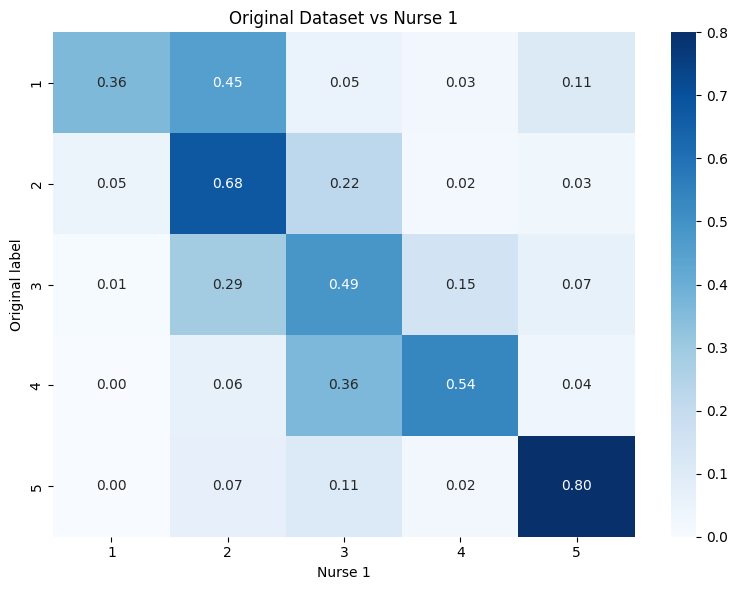

In [70]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_n1 = confusion_matrix(
    nurse1_cases["original_stage_if_available"],
    nurse1_cases["stage_1"],
    labels=[1,2,3,4,5]
)

cm_n1_norm = cm_n1.astype(float) / cm_n1.sum(axis=1)[:, None]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_n1_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Nurse 1")
plt.ylabel("Original label")
plt.title("Original Dataset vs Nurse 1")

plt.tight_layout()
plt.show()

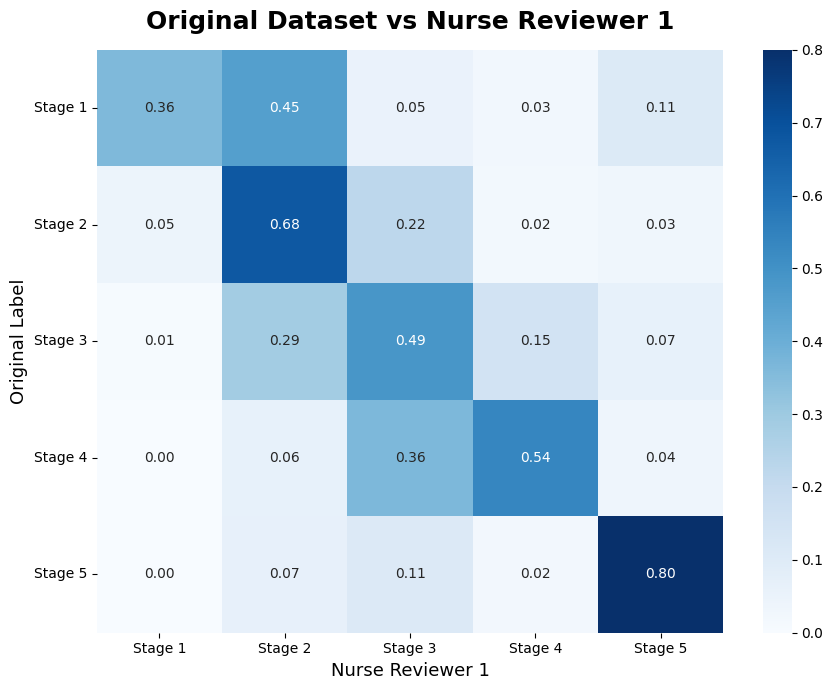

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix
cm_n1 = confusion_matrix(
    nurse1_cases["original_stage_if_available"],
    nurse1_cases["stage_1"],
    labels=[1, 2, 3, 4, 5]
)

# Normalize by row
cm_n1_norm = cm_n1.astype(float) / cm_n1.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_n1_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[
        "Stage 1", "Stage 2", "Stage 3",
        "Stage 4", "Stage 5"
    ],
    yticklabels=[
        "Stage 1", "Stage 2", "Stage 3",
        "Stage 4", "Stage 5"
    ],
    cbar=True
)

plt.title(
    "Original Dataset vs Nurse Reviewer 1",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Nurse Reviewer 1",
    fontsize=13
)

plt.ylabel(
    "Original Label",
    fontsize=13
)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

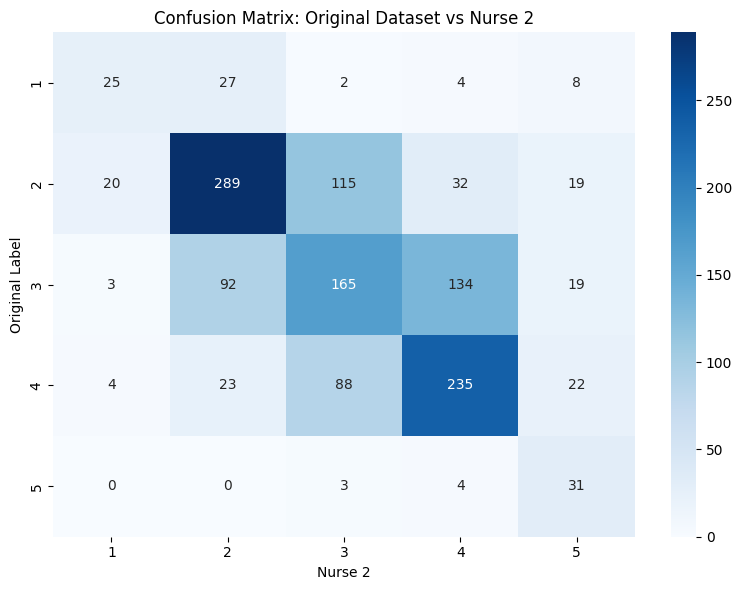

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_n2 = confusion_matrix(
    nurse2_cases["original_stage_if_available"],
    nurse2_cases["stage_2"],
    labels=[1,2,3,4,5]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_n2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Nurse 2")
plt.ylabel("Original Label")
plt.title("Confusion Matrix: Original Dataset vs Nurse 2")

plt.tight_layout()
plt.show()

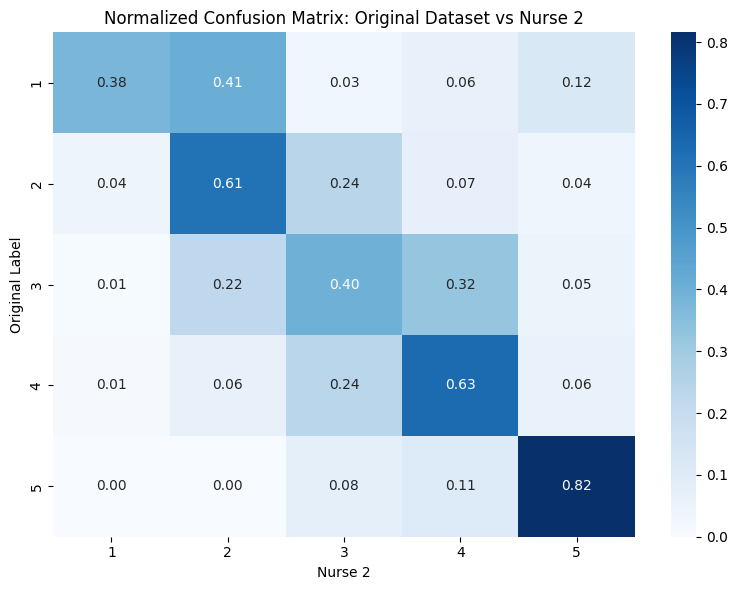

In [73]:
cm_n2_norm = cm_n2.astype(float) / cm_n2.sum(axis=1)[:, None]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_n2_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Nurse 2")
plt.ylabel("Original Label")
plt.title("Normalized Confusion Matrix: Original Dataset vs Nurse 2")

plt.tight_layout()
plt.show()

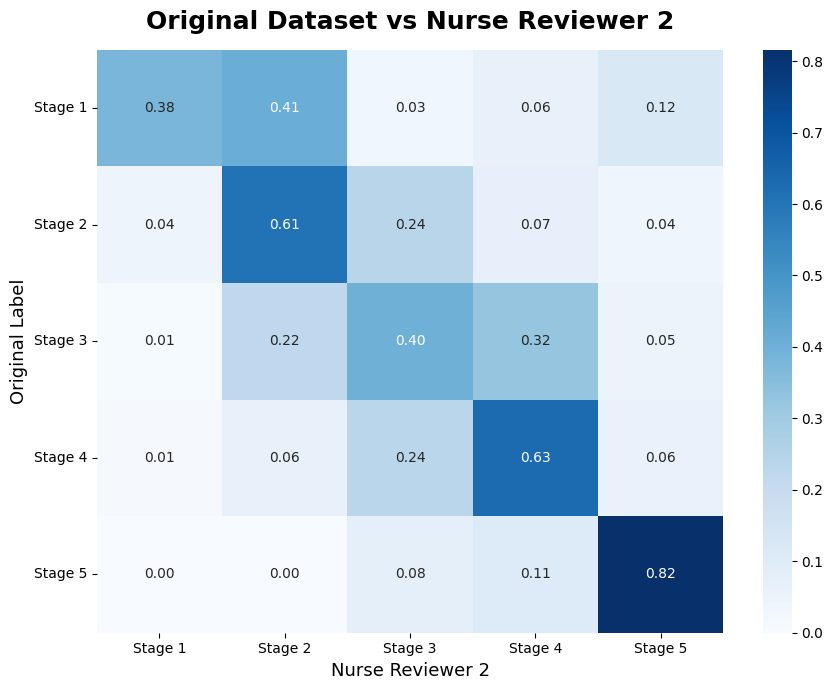

In [82]:
# Normalize by row
cm_n2_norm = cm_n2.astype(float) / cm_n2.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_n2_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[
        "Stage 1", "Stage 2", "Stage 3",
        "Stage 4", "Stage 5"
    ],
    yticklabels=[
        "Stage 1", "Stage 2", "Stage 3",
        "Stage 4", "Stage 5"
    ],
    cbar=True
)

plt.title(
    "Original Dataset vs Nurse Reviewer 2",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Nurse Reviewer 2",
    fontsize=13
)

plt.ylabel(
    "Original Label",
    fontsize=13
)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()